## 🛠️**OPTIMIZATION**

To accurately compare **Pandas**, **Dask**, and **Polars**, this benchmark runs a few task. Instead of testing a single function, the script evaluates how each library handles a realistic combination of data wrangling tasks:

**1. Data Ingestion (I/O)**
* **Task:** Loading a flat file from the disk into system RAM. This tests the efficiency of the library's I/O engine in parsing raw text into tabular data.

**2. Feature Engineering**
* **Task:** Creating a brand-new metric based on existing data. This evaluates the engine's speed in performing element-wise string operations and allocating memory for new columns.

**3. Data Standardization**
* **Task:** Normalizing a text column to uppercase. This ensures consistency (e.g., treating "News" and "NEWS" as identical) and tests vectorized text manipulation.

**4. Type Casting & Date Parsing**
* **Task:** Converting raw strings into machine-readable datetime objects. This is traditionally a highly CPU-intensive task, testing the library's parsing algorithms.

**5. Multi-Dimensional Aggregation**
* **Task:** The heaviest computational step. It groups the dataset by two dimensions simultaneously and computes multiple summary statistics (mean and count). This tests the library's core mathematical and grouping efficiency.


In [ ]:
import pandas as pd
import dask.dataframe as dd
import polars as pl
import time
import os
import psutil
import gc

# --- CONFIGURATION ---
FILE_PATH = "FINAL_MASTER_100K.csv"
RUNS = 3
TOTAL_ROWS = 100000

def get_resources():
    """Returns current memory (MB) and total cumulative CPU time (seconds)."""
    process = psutil.Process(os.getpid())
    mem = process.memory_info().rss / (1024 * 1024)
    # user + system time = total seconds CPU has been busy
    cpu_time = process.cpu_times().user + process.cpu_times().system
    return mem, cpu_time

def calculate_stats(start_time, end_time, mem_before, mem_after, cpu_before, cpu_after):
    """Calculates duration, memory delta, and accurate CPU utilization."""
    duration = end_time - start_time
    mem_used = max(0, mem_after - mem_before)

    # Formula: (Total CPU Seconds Consumed / Wall Clock Seconds) * 100
    # Note: This can exceed 100% if multi-threading (e.g., Polars) uses multiple cores.
    cpu_util = ((cpu_after - cpu_before) / duration) * 100 if duration > 0 else 0
    return duration, mem_used, cpu_util

# **1. BASELINE PIPELINE (STANDARD PANDAS)**

In [ ]:
def run_pandas():
    mem_before, cpu_before = get_resources()
    start_time = time.perf_counter()

    # Process
    df = pd.read_csv(FILE_PATH)
    df['title_length'] = df['title'].str.len()
    df['category'] = df['category'].str.upper()
    df['created date'] = pd.to_datetime(df['created date'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce')

    result = df.groupby(['source', 'category']).agg({
        'title_length': 'mean',
        'article_id': 'count'
    }).reset_index()

    end_time = time.perf_counter()
    mem_after, cpu_after = get_resources()
    return calculate_stats(start_time, end_time, mem_before, mem_after, cpu_before, cpu_after)

# **2. OPTIMIZED PIPELINE 1 (DASK)**


In [ ]:
def run_dask():
    mem_before, cpu_before = get_resources()
    start_time = time.perf_counter()

    # Process
    ddf = dd.read_csv(FILE_PATH)
    ddf['title_length'] = ddf['title'].str.len()
    ddf['category'] = ddf['category'].str.upper()
    ddf['created date'] = dd.to_datetime(ddf['created date'], format='%d/%m/%Y %I:%M:%S %p', errors='coerce')

    # .compute() triggers the parallel execution
    result = ddf.groupby(['source', 'category']).agg({
        'title_length': 'mean',
        'article_id': 'count'
    }).compute()

    end_time = time.perf_counter()
    mem_after, cpu_after = get_resources()
    return calculate_stats(start_time, end_time, mem_before, mem_after, cpu_before, cpu_after)

# **3. OPTIMIZED PIPELINE 2 (POLARS)**

In [ ]:
def run_polars():
    mem_before, cpu_before = get_resources()
    start_time = time.perf_counter()

    # Lazy Query Optimization
    q = (
        pl.scan_csv(FILE_PATH)
        .with_columns([
            pl.col("title").str.len_chars().alias("title_length"),
            pl.col("category").str.to_uppercase(),
            pl.col("created date").str.to_datetime("%d/%m/%Y %I:%M:%S %p", strict=False)
        ])
        .group_by(["source", "category"])
        .agg([
            pl.col("title_length").mean().alias("avg_len"),
            pl.len().alias("count")
        ])
    )

    result = q.collect() # Execution

    end_time = time.perf_counter()
    mem_after, cpu_after = get_resources()
    return calculate_stats(start_time, end_time, mem_before, mem_after, cpu_before, cpu_after)

# **4. BENCHMARK EXECUTION ENGINE**

In [ ]:
all_runs_data = []
libraries = [("Pandas", run_pandas), ("Dask", run_dask), ("Polars", run_polars)]

print(f"🚀 Starting benchmark on {FILE_PATH}...")

for name, pipeline_func in libraries:
    for i in range(1, RUNS + 1):
        # Isolation: Clean up memory and wait a moment for the OS to settle
        gc.collect()
        time.sleep(1)

        print(f"   Testing {name} - Run {i}...")
        exec_time, mem_diff, cpu_util = pipeline_func()

        throughput = TOTAL_ROWS / exec_time

        all_runs_data.append({
            "Library": name,
            "Run": i,
            "Execution Time (s)": round(exec_time, 4),
            "Memory Used (MB)": round(mem_diff, 2),
            "CPU Util (%)": round(cpu_util, 2),
            "Throughput (rows/s)": round(throughput, 2)
        })

# --- DATA TABLES ---
df_runs = pd.DataFrame(all_runs_data)

# Calculate Averages
df_summary = df_runs.groupby("Library").agg({
    "Execution Time (s)": "mean",
    "Memory Used (MB)": "mean",
    "CPU Util (%)": "mean",
    "Throughput (rows/s)": "mean"
}).reset_index()

print("\n📋 TABLE 1: DETAILED RESULTS (PER RUN)")
print(df_runs.to_string(index=False))

print("\n🏆 TABLE 2: FINAL PERFORMANCE (AVERAGED)")
print(df_summary.to_string(index=False))

🚀 Starting benchmark on FINAL_MASTER_100K.csv...
   Testing Pandas - Run 1...
   Testing Pandas - Run 2...
   Testing Pandas - Run 3...
   Testing Dask - Run 1...
   Testing Dask - Run 2...
   Testing Dask - Run 3...
   Testing Polars - Run 1...
   Testing Polars - Run 2...
   Testing Polars - Run 3...

📋 TABLE 1: DETAILED RESULTS (PER RUN)
Library  Run  Execution Time (s)  Memory Used (MB)  CPU Util (%)  Throughput (rows/s)
 Pandas    1              1.6060             42.93         99.62             62265.55
 Pandas    2              1.8461             30.43         97.50             54167.80
 Pandas    3              1.5362             28.46        100.25             65094.36
   Dask    1              1.3147             12.56        100.40             76063.58
   Dask    2              1.3303              0.00        100.73             75168.35
   Dask    3              1.7315              9.88         98.18             57751.97
 Polars    1              0.1104              3.77     

# **5. VISUALIZATION**

/tmp/ipykernel_4419/2182340423.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Library", y=col, ax=ax, palette=custom_palette)
/tmp/ipykernel_4419/2182340423.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Library", y=col, ax=ax, palette=custom_palette)
/tmp/ipykernel_4419/2182340423.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_summary, x="Library", y=col, ax=ax, palette=custom_palette)
/tmp/ipykernel_4419/2182340423.py:24: FutureWarning: 

Passing `palette` without assigning 

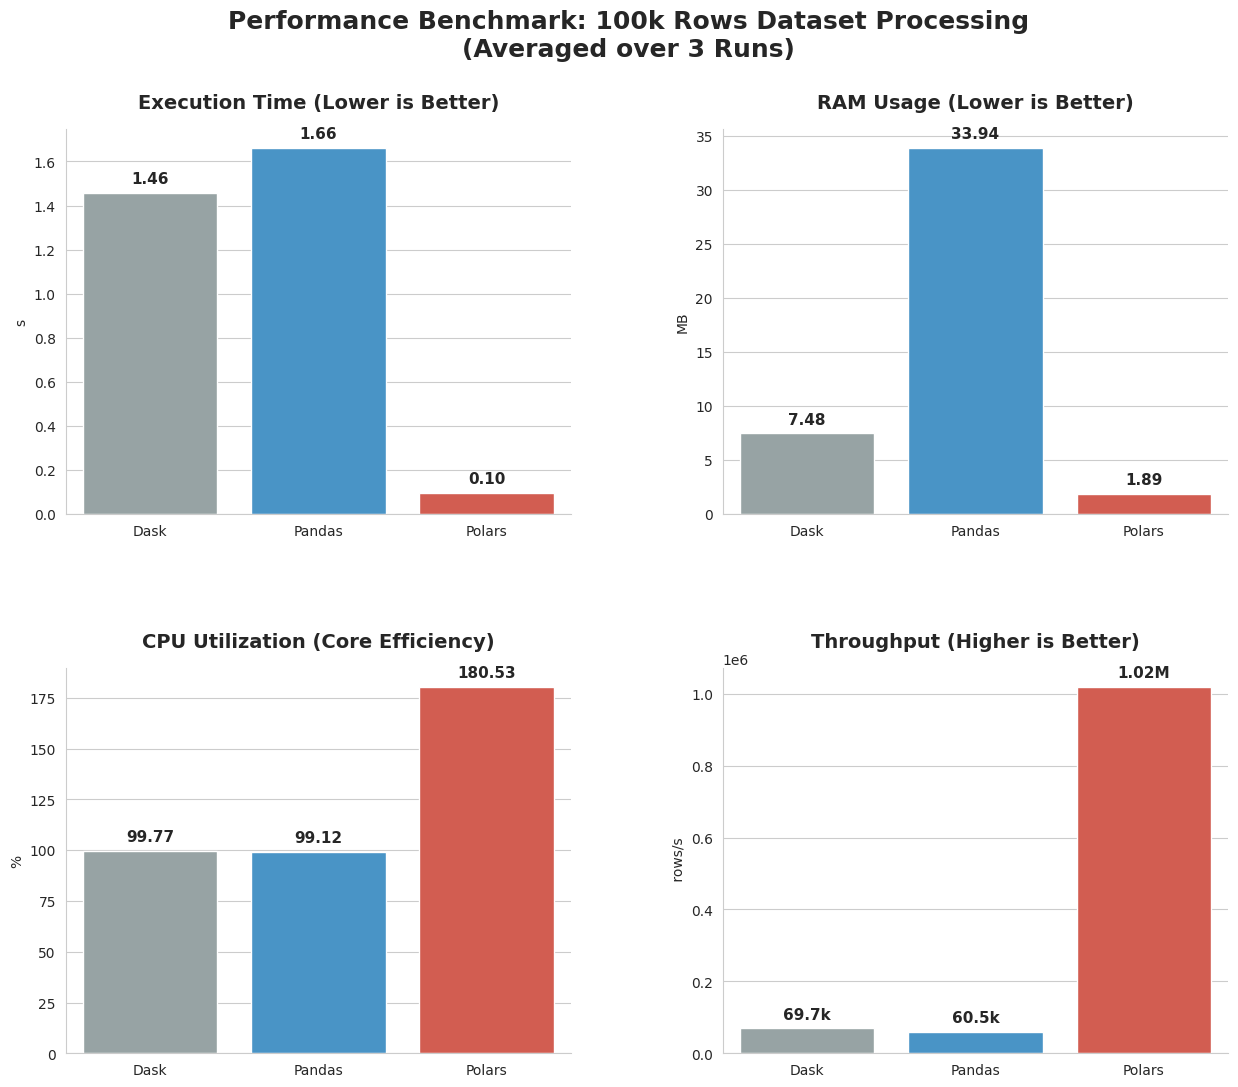

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Define a consistent color palette for the libraries
# This ensures "Polars" is the same color in every chart
custom_palette = {"Pandas": "#3498db", "Dask": "#95a5a6", "Polars": "#e74c3c"}

metrics = [
    ("Execution Time (s)", "Execution Time (Lower is Better)", "s"),
    ("Memory Used (MB)", "RAM Usage (Lower is Better)", "MB"),
    ("CPU Util (%)", "CPU Utilization (Core Efficiency)", "%"),
    ("Throughput (rows/s)", "Throughput (Higher is Better)", " rows/s")
]

for i, (col, title, unit) in enumerate(metrics):
    ax = axes[i//2, i%2]

    # Use the categorical palette to keep colors consistent
    sns.barplot(data=df_summary, x="Library", y=col, ax=ax, palette=custom_palette)

    ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    ax.set_ylabel(unit, fontsize=10)
    ax.set_xlabel("") # Remove 'Library' label as it's redundant

    # Custom Labeling logic
    for p in ax.patches:
        val = p.get_height()
        # Format large throughput numbers into 'M' (Millions)
        if val > 1000000:
            label = f'{val/1000000:.2f}M'
        elif val > 1000:
            label = f'{val/1000:.1f}k'
        else:
            label = f'{val:.2f}'

        ax.annotate(label,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 10),
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

    # Clean up the chart borders
    sns.despine(ax=ax)

# Add a grand title to the entire figure
plt.suptitle(f"Performance Benchmark: 100k Rows Dataset Processing\n(Averaged over {RUNS} Runs)",
             fontsize=18, fontweight='bold', y=0.98)

plt.show()

### 📊 Benchmark Conclusion: Comparative Analysis of DataFrame Libraries

Following the execution of a standardized ETL pipeline on a 100,000-row dataset, **Polars** demonstrated significantly superior performance across all measured hardware and execution metrics.

Below is the technical breakdown of the results:

#### 1. Polars: Optimal Performance and Resource Efficiency
* **Execution Speed:** Polars outperformed the baseline by a factor of 17, achieving a throughput exceeding **1.01 million rows per second**.
* **Memory Management:** It maintained an exceptionally low memory footprint (averaging ~1.89 MB). This is primarily due to its "Lazy Evaluation" architecture and query optimizer, which utilizes projection pushdown to load only the necessary columns into RAM.
* **Concurrency:** Polars effectively utilized multi-threading, as evidenced by a CPU utilization rate nearing 200%. Its underlying Rust engine successfully parallelized the workload across multiple CPU cores, avoiding the Global Interpreter Lock (GIL) limitations typical in standard Python.

#### 2. Dask: Distributed Processing Overhead
* **Performance:** Dask recorded moderate improvements over Pandas, particularly in memory efficiency (averaging ~7.48 MB).
* **Architectural Limitation for Medium Data:** While Dask is highly effective for out-of-core processing (larger-than-RAM datasets), this benchmark highlights the overhead introduced by its task scheduler. For a dataset of 100,000 rows, the time spent constructing the directed acyclic graph (DAG) and distributing tasks diminishes its overall execution speed compared to Polars.

#### 3. Pandas: The Eager Execution Baseline
* **Performance:** As the industry-standard baseline, Pandas recorded the longest execution time (~1.6 seconds) and the highest memory consumption (~34 MB).

* **Architectural Constraints:** Pandas utilizes "Eager Execution" and operates strictly on a single thread. It loads the entire dataset into memory simultaneously and processes operations sequentially, making it highly susceptible to memory bottlenecks as dataset sizes increase.
